In [1]:

# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score



In [2]:
import os
print(os.getcwd())

C:\Users\harsh\InshipAssignment\Taxi_Fare


In [3]:
df = pd.read_csv("train1.csv")

print(df.head())

                             key  fare_amount          pickup_datetime  \
0   2011-01-24 18:05:00.00000025         9.30  2011-01-24 18:05:00 UTC   
1   2013-04-23 20:57:00.00000029         5.00  2013-04-23 20:57:00 UTC   
2  2011-01-09 03:01:00.000000167        16.50  2011-01-09 03:01:00 UTC   
3   2010-04-07 04:15:00.00000012         8.10  2010-04-07 04:15:00 UTC   
4   2013-11-05 16:53:00.00000052        51.83  2013-11-05 16:53:00 UTC   

   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.983768        40.738037         -73.982185         40.757298   
1        -73.967943        40.799842         -73.964820         40.810153   
2        -73.983637        40.760198         -73.942912         40.824983   
3        -74.002312        40.733603         -73.985807         40.762793   
4        -73.863982        40.769815         -74.009212         40.715652   

   passenger_count  
0                1  
1                1  
2                2  
3       

In [4]:

# checking dataset shape

print(df.shape)

# checking column names

print(df.columns)

# checking dataset information

print(df.info())

# checking missing values

print(df.isnull().sum())


(100000, 8)
Index(['key', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                100000 non-null  str    
 1   fare_amount        100000 non-null  float64
 2   pickup_datetime    100000 non-null  str    
 3   pickup_longitude   100000 non-null  float64
 4   pickup_latitude    100000 non-null  float64
 5   dropoff_longitude  99998 non-null   float64
 6   dropoff_latitude   99998 non-null   float64
 7   passenger_count    100000 non-null  int64  
dtypes: float64(5), int64(1), str(2)
memory usage: 6.1 MB
None
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    2
dropoff_latitude  

In [5]:

# checking rows with missing values

print(df[df.isnull().any(axis=1)])

# removing missing values

df = df.dropna()

# checking again

print(df.isnull().sum())



                               key  fare_amount          pickup_datetime  \
38273  2012-12-11 12:31:18.0000002         25.5  2012-12-11 12:31:18 UTC   
76139  2013-07-01 12:25:52.0000002          9.7  2013-07-01 12:25:52 UTC   

       pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
38273        -73.975868        40.752144                NaN               NaN   
76139        -73.982494        40.768468                NaN               NaN   

       passenger_count  
38273                0  
76139                0  
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64


In [6]:
# converting pickup_datetime to datetime type

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

# checking datatype

print(df.dtypes)

key                                  str
fare_amount                      float64
pickup_datetime      datetime64[us, UTC]
pickup_longitude                 float64
pickup_latitude                  float64
dropoff_longitude                float64
dropoff_latitude                 float64
passenger_count                    int64
dtype: object


In [7]:
# extracting hour, day and month from datetime

df['hour'] = df['pickup_datetime'].dt.hour

df['day'] = df['pickup_datetime'].dt.day

df['month'] = df['pickup_datetime'].dt.month

# checking first 5 rows

print(df[['pickup_datetime', 'hour', 'day', 'month']].head())

            pickup_datetime  hour  day  month
0 2011-01-24 18:05:00+00:00    18   24      1
1 2013-04-23 20:57:00+00:00    20   23      4
2 2011-01-09 03:01:00+00:00     3    9      1
3 2010-04-07 04:15:00+00:00     4    7      4
4 2013-11-05 16:53:00+00:00    16    5     11


In [8]:
# checking basic statistics

print(df.describe())

        fare_amount  pickup_longitude  pickup_latitude  dropoff_longitude  \
count  99998.000000      99998.000000     99998.000000       99998.000000   
mean      11.314505        -72.571181        39.934408         -72.520275   
std        9.666939         11.419961         6.516594          15.142902   
min       -3.500000      -1329.480383      -764.564600        -735.050000   
25%        6.000000        -73.992082        40.734725         -73.991453   
50%        8.500000        -73.981803        40.752612         -73.980257   
75%       12.500000        -73.967070        40.767192         -73.963848   
max      332.000000         40.786837        52.521408        3382.125693   

       dropoff_latitude  passenger_count          hour           day  \
count      99998.000000     99998.000000  99998.000000  99998.000000   
mean          39.932603         1.689544     13.524720     15.706134   
std            7.096120         1.311282      6.526741      8.703760   
min        -1160.2

In [9]:
# removing invalid fare values

df = df[df['fare_amount'] > 0]

# removing extremely high fares

df = df[df['fare_amount'] < 100]

# removing invalid passenger counts

df = df[df['passenger_count'] > 0]

# checking updated statistics

print(df.describe())

        fare_amount  pickup_longitude  pickup_latitude  dropoff_longitude  \
count  99631.000000      99631.000000     99631.000000       99631.000000   
mean      11.277646        -72.571244        39.934272         -72.523824   
std        9.345204         11.424484         6.519814          15.149624   
min        0.010000      -1329.480383      -764.564600        -735.050000   
25%        6.000000        -73.992081        40.734728         -73.991450   
50%        8.500000        -73.981805        40.752605         -73.980258   
75%       12.500000        -73.967100        40.767182         -73.963860   
max       99.900000         40.786837        52.521408        3382.125693   

       dropoff_latitude  passenger_count          hour           day  \
count      99631.000000     99631.000000  99631.000000  99631.000000   
mean          39.934480         1.695245     13.523492     15.706758   
std            7.095485         1.310049      6.527643      8.703410   
min        -1160.2

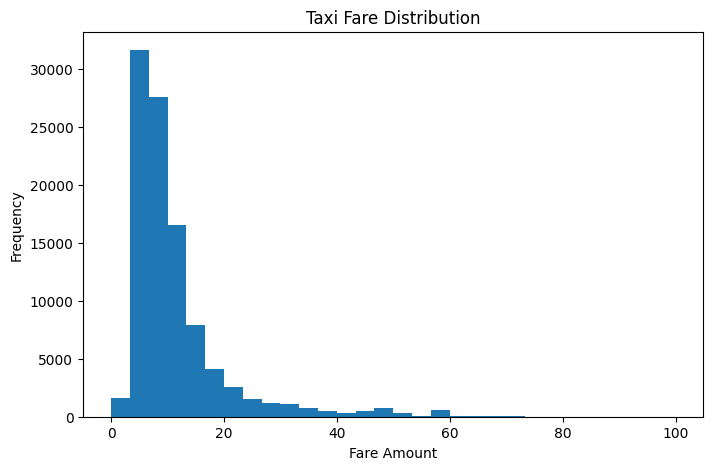

In [10]:
# plotting fare amount distribution

plt.figure(figsize=(8,5))

plt.hist(df['fare_amount'], bins=30)

plt.title("Taxi Fare Distribution")

plt.xlabel("Fare Amount")

plt.ylabel("Frequency")

plt.show()

In [11]:
# selecting input features

X = df[['pickup_longitude',
        'pickup_latitude',
        'dropoff_longitude',
        'dropoff_latitude',
        'passenger_count',
        'hour',
        'day',
        'month']]

# target column

y = df['fare_amount']

# checking shapes

print(X.shape)

print(y.shape)

(99631, 8)
(99631,)


In [12]:
# splitting dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# checking shapes

print(X_train.shape)

print(X_test.shape)

(79704, 8)
(19927, 8)


In [13]:
# creating linear regression model

lr = LinearRegression()

# training model

lr.fit(X_train, y_train)

# predictions

y_pred_lr = lr.predict(X_test)

# checking some predictions

print(y_pred_lr[:5])

[10.96732664 10.9091743  10.88019471 11.2121433  11.34454433]


In [14]:
# evaluating linear regression model

mae = mean_absolute_error(y_test, y_pred_lr)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")

print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

Linear Regression Results
MAE: 5.933260668003056
RMSE: 9.216066031791193
R2 Score: 0.000609450669866729


In [15]:
# creating decision tree model

dt = DecisionTreeRegressor(random_state=42)

# training model

dt.fit(X_train, y_train)

# predictions

y_pred_dt = dt.predict(X_test)

# evaluation

mae_dt = mean_absolute_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")

print("MAE:", mae_dt)

print("RMSE:", rmse_dt)

print("R2 Score:", r2_dt)

Decision Tree Results
MAE: 3.2135497064284637
RMSE: 6.150659581275759
R2 Score: 0.554869385441193


In [ ]:
# creating random forest model

rf = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)

# training model

rf.fit(X_train, y_train)

# predictions

y_pred_rf = rf.predict(X_test)

# evaluation

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")

print("MAE:", mae_rf)

print("RMSE:", rmse_rf)

print("R2 Score:", r2_rf)

In [ ]:
# comparing model R2 scores

models = ['Linear Regression', 'Decision Tree', 'Random Forest']

scores = [r2, r2_dt, r2_rf]

plt.figure(figsize=(8,5))

plt.bar(models, scores)

plt.title("Model Comparison using R2 Score")

plt.ylabel("R2 Score")

plt.show()

# Conclusion

In this project, taxi fare prediction was performed using different machine learning regression models.

First, the dataset was cleaned by handling missing values and removing invalid fare and passenger values. Then feature engineering was performed by extracting hour, day, and month from the pickup datetime column.

Three machine learning models were trained and compared:

* Linear Regression
* Decision Tree Regressor
* Random Forest Regressor

Among all models, Random Forest Regressor performed the best with the highest R2 score and lowest error values.

This project helped in understanding:

* data preprocessing
* feature engineering
* outlier handling
* model training
* model evaluation
* comparison of machine learning models
